Установка зависимостей

In [1]:
# Run in Goggle colab only
from google.colab import drive
drive.mount('/gdrive')
# the project's folder
%cd /gdrive/'My Drive'/lab5
%pip install -r /gdrive/'My Drive'/lab5/requirements.txt

Mounted at /gdrive
/gdrive/My Drive/lab5


In [2]:
%ls

images/  lab5-2.ipynb  requirements.txt  results/


Импорт необходимых библиотек

In [3]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

Загрузка изображения

In [17]:
image = cv2.imread('images/img7.jpg')  # Замените на имя вашего файла

# Проверка загрузки изображения
if image is None:
    print("Ошибка: Не удалось загрузить изображение.")
    exit()

Выполнение сегментации с использованием k-means

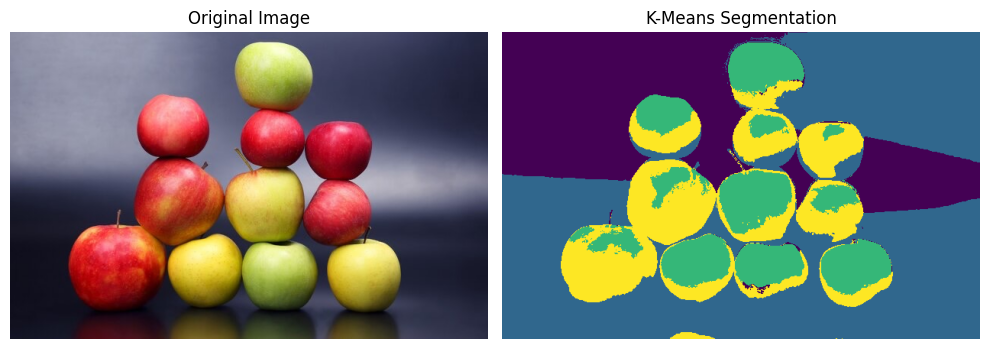

In [5]:
def kmeans_segmentation(image, n_clusters=5):
    """
    Сегментирует изображение с помощью алгоритма K-Means.

    Args:
        image (numpy.ndarray): Исходное изображение (цветное, в формате BGR).
        n_clusters (int): Количество кластеров для K-Means.  Обычно нужно настроить.

    Returns:
        numpy.ndarray: Сегментированное изображение (где каждый пиксель имеет метку кластера).
                       Значения пикселей соответствуют номерам кластеров (0, 1, 2, ...).
    """

    # Преобразуем изображение в список пикселей
    pixels = image.reshape((-1, 3))  # Преобразуем в массив (высота*ширина, 3)

    # Запускаем K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10) # n_init указывается явно
    cluster_labels = kmeans.fit_predict(pixels)  # Обучение и предсказание

    # Преобразуем метки кластеров обратно в форму изображения
    segmented_image = cluster_labels.reshape(image.shape[:2])  # Восстанавливаем форму

    return segmented_image


# Выполняем K-Means сегментацию
# Изменяя параметр n_clusters добиваемся правильной сегментации
segmented_image = kmeans_segmentation(image, n_clusters=4)  # 4 кластера (примерно: фон, красные, желтые, зеленые)

# Отображаем результаты (с использованием Matplotlib)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Отображаем исходное изображение
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(segmented_image, cmap='viridis')  # Отображаем сегментированное изображение
plt.title("K-Means Segmentation")
plt.axis('off')
plt.tight_layout()
plt.show()

Сегментация по порогу

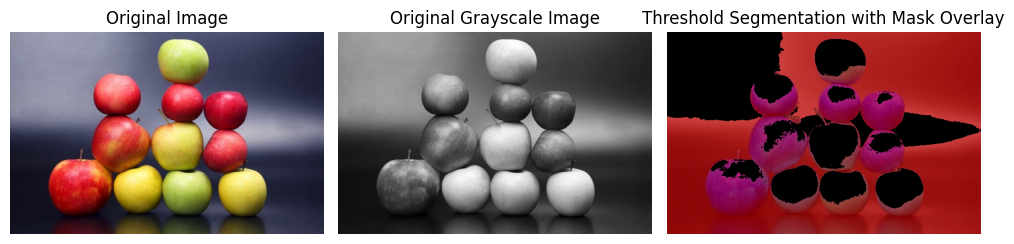

In [6]:
def threshold_segmentation_mask_overlay(image, threshold_value=127, max_value=255, threshold_type=cv2.THRESH_BINARY_INV, overlay_color=(255, 0, 0), overlay_alpha=0.5):
    """
    Выполняет пороговую сегментацию, создает маску, накладывает маску на исходное изображение
    и возвращает только часть изображения, соответствующую маске.

    Args:
        image (numpy.ndarray): Исходное изображение (цветное, BGR).
        threshold_value (int): Пороговое значение.
        max_value (int): Максимальное значение для пикселей.
        threshold_type (int): Тип пороговой обработки (обычно cv2.THRESH_BINARY_INV).
        overlay_color (tuple): Цвет наложения маски (BGR).  По умолчанию - синий.
        overlay_alpha (float): Прозрачность наложения маски (от 0 до 1).

    Returns:
        numpy.ndarray:  Часть изображения, соответствующая маске, с наложенной маской.
    """

    # 1. Преобразование в оттенки серого
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2. Пороговая обработка
    ret, thresholded_image = cv2.threshold(gray_image, threshold_value, max_value, threshold_type)

    # 3. Создаем маску
    mask = thresholded_image

    # 4. Создаем цветное изображение для наложения
    overlay = np.zeros_like(image, dtype=np.uint8)
    overlay[:] = overlay_color  # Задаем цвет наложения

    # 5. Накладываем маску на изображение (Используем bitwise_and для начала)
    masked_image = cv2.bitwise_and(image, image, mask=mask)

    # 6. Накладываем overlay (упрощенный вариант): где маска белая, там overlay
    for c in range(3): # Для каждого цветового канала
        masked_image[:, :, c] = np.where(mask == 255, (1 - overlay_alpha) * masked_image[:, :, c] + overlay_alpha * overlay[:, :, c], masked_image[:, :, c])


    return masked_image

# Преобразуем в оттенки серого
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Выполняем пороговую сегментацию
# Изменяя параметры threshold_value и max_value, можно менять качество сегментации.
# Выполняем пороговую сегментацию, наложение маски, и вывод результата
segmented_image = threshold_segmentation_mask_overlay(
        image.copy(),
        threshold_value=127,
        threshold_type=cv2.THRESH_BINARY_INV,
        overlay_color=(255, 0, 0), # Синий цвет наложения
        overlay_alpha=0.5 # Прозрачность 0.5
    )

# Отображаем результаты (с использованием Matplotlib)
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Отображаем исходное изображение
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(gray_image, cmap='gray')  # Отображаем исходное изображение в оттенках серого
plt.title("Original Grayscale Image")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(segmented_image)  # Отображаем сегментированное изображение
plt.title("Threshold Segmentation with Mask Overlay")
plt.axis('off')
plt.tight_layout()
plt.show()

Сегментация с применением алгоритма Оцу

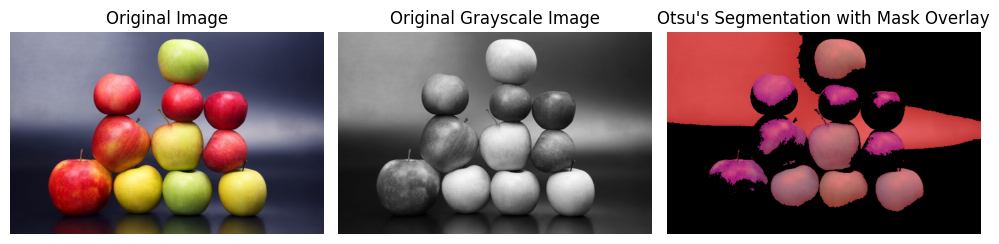

In [7]:
def otsu_segmentation_mask_overlay(image, overlay_color=(255, 0, 0), overlay_alpha=0.5):
    """
    Выполняет пороговую сегментацию с использованием алгоритма Оцу, создает маску и накладывает ее на изображение.

    Args:
        image (numpy.ndarray): Исходное изображение (цветное, BGR).
        overlay_color (tuple): Цвет наложения маски (BGR).
        overlay_alpha (float): Прозрачность наложения маски (от 0 до 1).

    Returns:
        numpy.ndarray: Изображение с наложенной маской.
    """

    # 1. Преобразование в оттенки серого
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2. Пороговая обработка Otsu
    ret, thresholded_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 3. Создаем маску
    mask = thresholded_image

    # 4. Наложение маски на изображение
    # Создаем overlay
    overlay = np.zeros_like(image, dtype=np.uint8)
    overlay[:] = overlay_color

    # 5. Накладываем маску
    masked_image = cv2.bitwise_and(image, image, mask=mask)

    # 6. Накладываем overlay на исходное изображение, используя маску
    for c in range(3):  # B, G, R
        masked_image[:, :, c] = np.where(mask == 255, \
            (1 - overlay_alpha) * masked_image[:, :, c] + overlay_alpha * overlay[:, :, c], \
                masked_image[:, :, c])

    return masked_image

# Выполняем пороговую сегментацию Оцу
segmented_image = otsu_segmentation_mask_overlay(
    image.copy(),  # Важно использовать копию!
    overlay_color=(255, 0, 0),  # Синий
    overlay_alpha=0.5
)

# Отображаем результаты (с использованием Matplotlib)
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Отображаем исходное изображение
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(gray_image, cmap='gray')  # Отображаем исходное изображение
plt.title("Original Grayscale Image")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(segmented_image)  # Отображаем сегментированное изображение
plt.title("Otsu's Segmentation with Mask Overlay")
plt.axis('off')
plt.tight_layout()
plt.show()

Сегментация водоразделом

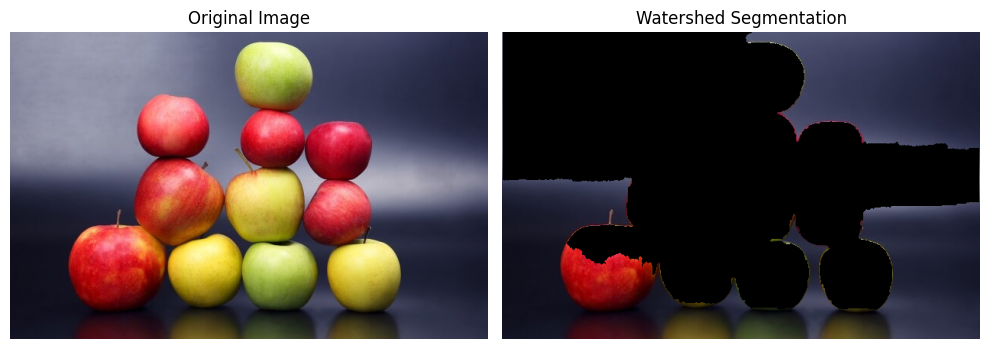

In [8]:
def watershed_segmentation(image, threshold):
    """
    Выполняет сегментацию изображения с использованием метода водораздела и удаляет фон.

    Args:
        image (numpy.ndarray): Исходное цветное изображение (BGR).

    Returns:
        numpy.ndarray: Сегментированное изображение, где фон удален (прозрачный).
    """

    # 1. Преобразование в оттенки серого
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 2. Пороговая обработка (используем Otsu для автоматического определения порога)
    ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 3. Морфологические операции для удаления шума
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # 4. Определение "точного" фона (sure background)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    # 5. Определение "точного" переднего плана (sure foreground) с использованием преобразования расстояний
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(dist_transform, threshold * dist_transform.max(), 255, 0) # Регулируем порог (0.7)

    # 6. Находим "неизвестную" область (unknown region)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # 7. Маркировка маркеров (Marker labeling)
    ret, markers = cv2.connectedComponents(sure_fg)

    # 8. Увеличиваем все метки на 1, чтобы фон не был 0
    markers = markers + 1

    # 9. Помечаем неизвестную область нулем
    markers[unknown == 255] = 0

    # 10. Применяем алгоритм водораздела
    markers = cv2.watershed(image, markers)

    # 11. Создаем маску для удаления фона
    mask = np.uint8(markers != 1)  # 1 - это фон, делаем маску
    masked_image = cv2.bitwise_and(image, image, mask=mask) # Применяем маску

    # 12. Сделаем фон прозрачным (RGBA)
    b, g, r = cv2.split(masked_image)
    alpha = mask
    rgba = cv2.merge((b, g, r, alpha))  #  b, g, r, alpha

    return rgba

threshold = 0.4

# Выполняем сегментацию методом водораздела
segmented_image = watershed_segmentation(image.copy(), threshold) # Важно работать с копией

# Отображаем результаты (с использованием Matplotlib)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Отображаем исходное изображение
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB))  # Отображаем сегментированное изображение
plt.title("Watershed Segmentation")
plt.axis('off')
plt.tight_layout()
plt.show()

Сегментация активными контурами

<ipython-input-9-94a5cd3aba99>:43: RuntimeWarning: invalid value encountered in cast
  ix = np.clip(np.round(contour[:, 0]).astype(int), 0, w-1)
<ipython-input-9-94a5cd3aba99>:44: RuntimeWarning: invalid value encountered in cast
  iy = np.clip(np.round(contour[:, 1]).astype(int), 0, h-1)
<ipython-input-9-94a5cd3aba99>:51: RuntimeWarning: overflow encountered in matmul
  contour[:, 0] = A_inv @ (contour[:, 0] + ex)
<ipython-input-9-94a5cd3aba99>:52: RuntimeWarning: overflow encountered in matmul
  contour[:, 1] = A_inv @ (contour[:, 1] + ey)
<ipython-input-9-94a5cd3aba99>:56: RuntimeWarning: invalid value encountered in cast
  contour_int = np.clip(np.round(contour).astype(int), [0, 0], [w-1, h-1])


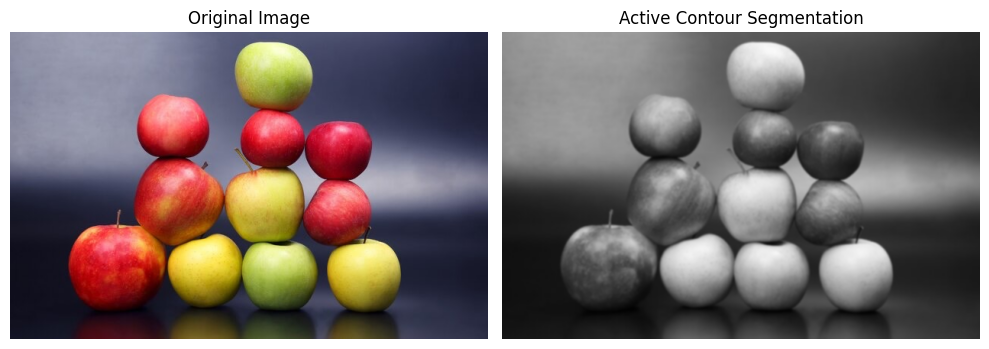

In [9]:
def active_contour_segmentation(image, initial_contour, alpha=0.01, beta=0.1, w_line=0.5,
                w_edge=0.5, iterations=200):
    """
    Сегментация изображения с использованием активных контуров (змеек).
    """
    # 1. Подготовка данных
    h, w = image.shape
    y, x = np.mgrid[0:h, 0:w]

    # 2. Вычисление внешних сил
    # Сила линии (Line force)
    f_line = -image.astype(np.float64)  # Инвертируем, если объекты темнее фона

    # Силы градиента (Edge force)
    gradient_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gradient_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Нормализация градиентов
    max_grad = max(np.max(np.abs(gradient_x)), np.max(np.abs(gradient_y))) or 1
    gradient_x /= max_grad
    gradient_y /= max_grad

    # Нормализация силы линии
    f_line = (f_line - np.min(f_line)) / (np.max(f_line) - np.min(f_line))

    # 3. Вычисление матрицы A (Внутренние силы)
    n_points = len(initial_contour)
    A = np.zeros((n_points, n_points))
    for i in range(n_points):
        A[i, i] = 2 * alpha + 6 * beta
        A[i, (i - 1) % n_points] = -alpha - 4 * beta
        A[i, (i + 1) % n_points] = -alpha - 4 * beta
        A[i, (i - 2) % n_points] = beta
        A[i, (i + 2) % n_points] = beta

    # Регуляризация матрицы
    A_inv = np.linalg.inv(A + np.eye(n_points) * 1e-8)

    # 4. Итерации
    contour = initial_contour.copy().astype(np.float64)
    for _ in range(iterations):
        # Получение координат с проверкой границ
        ix = np.clip(np.round(contour[:, 0]).astype(int), 0, w-1)
        iy = np.clip(np.round(contour[:, 1]).astype(int), 0, h-1)

        # Вычисление внешних сил с учетом направления градиентов
        ex = w_line * f_line[iy, ix] + w_edge * gradient_x[iy, ix]
        ey = w_line * f_line[iy, ix] + w_edge * gradient_y[iy, ix]

        # Обновление контура с учетом внутренних сил
        contour[:, 0] = A_inv @ (contour[:, 0] + ex)
        contour[:, 1] = A_inv @ (contour[:, 1] + ey)

    # 5. Рисуем контур
    segmented_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    contour_int = np.clip(np.round(contour).astype(int), [0, 0], [w-1, h-1])

    for i in range(n_points):
        pt1 = tuple(contour_int[i])
        pt2 = tuple(contour_int[(i+1) % n_points])
        cv2.line(segmented_image, pt1, pt2, (0, 255, 0), 1)

    return segmented_image, contour_int

# 2. Преобразуем в оттенки серого
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# *** Добавлено: Размытие для уменьшения шума ***
gray_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# 3. Задаем начальный контур (примерно вокруг яблока).  Важно, чтобы контур был замкнутым
# Пример: круг
h, w = gray_image.shape
center_x, center_y = w // 2, h // 2
radius = min(w, h) // 4
num_points = 150
initial_contour = np.array([[center_x + radius * np.cos(2 * np.pi * i / num_points),
                                center_y + radius * np.sin(2 * np.pi * i / num_points)]
                            for i in range(num_points)])

# Преобразуем в float32
initial_contour = np.float32(initial_contour)

# 4. Выполняем сегментацию активными контурами
segmented_image, final_contour = active_contour_segmentation(gray_image, initial_contour,
                            alpha=0.001, beta=0.1, w_line=0.5, w_edge=0.5, iterations=200) # Изменено alpha

# 5. Отображаем результаты
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Отображаем исходное изображение
plt.title("Original Image")
plt.axis('off')  # Отключаем оси

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(segmented_image, cv2.COLOR_BGR2RGB))  # конвертируем для matplotlib
plt.title("Active Contour Segmentation")
plt.axis('off')
plt.tight_layout()
plt.show()

Сегментация по цвету яблок (красное, желтое, зеленое)

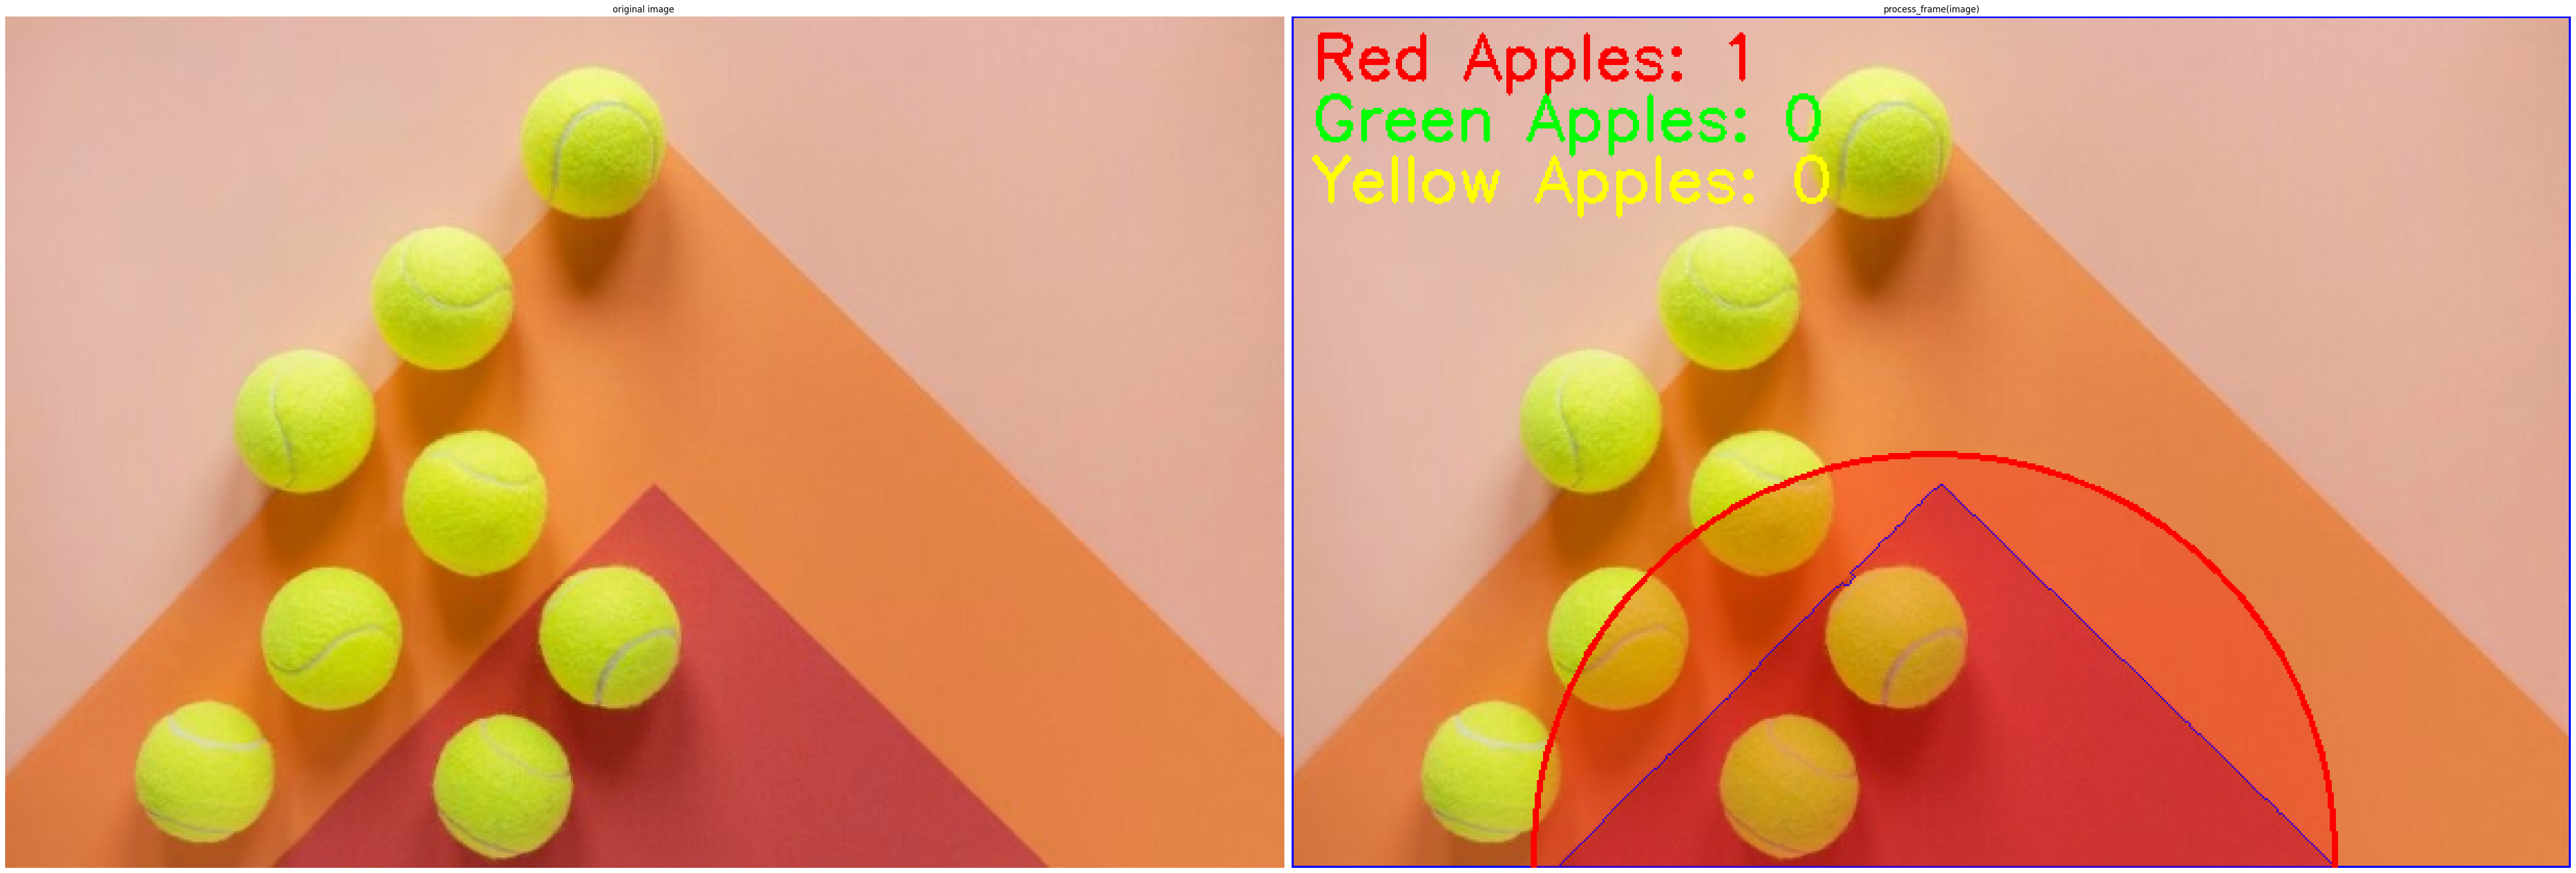

In [19]:
def process_frame(frame):
    """
    Обнаруживает контуры яблок трех цветов (красный, желтый, зеленый),
    сегментирует яблоки с прозрачностью 25% и подсчитывает их количество.

    Args:
        frame: Исходное изображение (NumPy массив).

    Returns:
        Tuple: (frame, red_count, green_count, yellow_count)
               frame: Обработанное изображение с прозрачной заливкой.
               red_count: Количество красных яблок.
               green_count: Количество зеленых яблок.
               yellow_count: Количество желтых яблок.
    """

    original_height, original_width = frame.shape[:2]
    scale_factor = 1.0 # Изначально коэффициент масштабирования 1.0
    resized = False
    scale_size = 800    # pixels

    # Проверяем, нужно ли изменять размер изображения
    if original_width > scale_size or original_height > scale_size:
        resized = True
        # Вычисляем коэффициент масштабирования, чтобы большая сторона стала scale_size
        scale_factor = min(scale_size / original_width, scale_size / original_height)

        # Изменяем размер изображения
        width = int(original_width * scale_factor)
        height = int(original_height * scale_factor)
        frame = cv2.resize(frame, (width, height), interpolation=cv2.INTER_AREA)

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # ---- Цветовые диапазоны (HSV) ----
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    lower_yellow = np.array([20, 100, 100])  # Примерные значения. Нужна точная настройка
    upper_yellow = np.array([30, 255, 255])  # Примерные значения. Нужна точная настройка

    # ---- Параметры ----
    kernel = np.ones((7, 7), np.uint8)
    min_area = 3500
    coverage_threshold = 1.00  # 85%
    alpha = 0.25  # Прозрачность (25%)

    # ---- Создание масок ----
    mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask_red = cv2.bitwise_or(mask_red1, mask_red2)
    mask_red = mask_red.astype(np.uint8)

    mask_green = cv2.inRange(hsv, lower_green, upper_green)
    mask_green = mask_green.astype(np.uint8)

    mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)
    mask_yellow = mask_yellow.astype(np.uint8)

    # ---- Морфологические операции ----
    mask_red = cv2.morphologyEx(mask_red, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_red = cv2.morphologyEx(mask_red, cv2.MORPH_CLOSE, kernel, iterations=1)
    mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, kernel, iterations=1)
    mask_yellow = cv2.morphologyEx(mask_yellow, cv2.MORPH_OPEN, kernel, iterations=1)
    mask_yellow = cv2.morphologyEx(mask_yellow, cv2.MORPH_CLOSE, kernel, iterations=1)

    # ---- Объединение масок ----
    mask = cv2.bitwise_or(mask_red, mask_green)
    mask = cv2.bitwise_or(mask, mask_yellow)
    mask = mask.astype(np.uint8)

    # ---- Watershed Segmentation ----
    dist_transform = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(dist_transform, 0.99 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    sure_bg = cv2.dilate(mask, kernel, iterations=10)
    unknown = cv2.subtract(sure_bg, sure_fg)

    ret, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    markers = cv2.watershed(frame, markers)
    frame[markers == -1] = [255, 0, 0]  # Границы между яблоками (синий)

    # ---- Поиск контуров и определение цвета ----
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    red_apple_count = 0
    green_apple_count = 0
    yellow_apple_count = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > min_area:
            mask_contour = np.zeros_like(mask, dtype=np.uint8)
            cv2.drawContours(mask_contour, [cnt], -1, 255, -1)

            # Вычисляем площадь пересечения контура с каждой цветовой маской
            area_red = np.sum(mask_contour & mask_red)
            area_green = np.sum(mask_contour & mask_green)
            area_yellow = np.sum(mask_contour & mask_yellow)

            # Вычисляем процент покрытия каждым цветом
            coverage_red = area_red / area
            coverage_green = area_green / area
            coverage_yellow = area_yellow / area

            # Проверяем, какой цвет преобладает и превышает порог покрытия
            if coverage_red > coverage_threshold and coverage_red > coverage_green \
                and coverage_red > coverage_yellow:
                color = (0, 0, 255)  # Красный
                red_apple_count += 1
            elif coverage_green > coverage_threshold and coverage_green > coverage_red \
                and coverage_green > coverage_yellow:
                color = (0, 255, 0)  # Зеленый
                green_apple_count += 1
            elif coverage_yellow > coverage_threshold and coverage_yellow > coverage_red \
                and coverage_yellow > coverage_green:
                color = (0, 255, 255)  # Желтый
                yellow_apple_count += 1
            else:
                color = None  # Ни один цвет не преобладает

            if color:
                # Вычисление bounding circle
                (x, y), radius = cv2.minEnclosingCircle(cnt)
                center = (int(x), int(y))
                radius = int(radius)

                # Создаем маску окружности
                circle_mask = np.zeros_like(frame, dtype=np.uint8)
                cv2.circle(circle_mask, center, radius, (255, 255, 255), cv2.FILLED)
                circle_mask = cv2.cvtColor(circle_mask, cv2.COLOR_BGR2GRAY)

                # Создаем прозрачную маску
                overlay = frame.copy()
                overlay[:] = color  # Заливаем всю область цветом

                # Используем маску окружности для прозрачной заливки только внутри круга
                frame = np.where(circle_mask[:,:,None] > 0, cv2.addWeighted(overlay, alpha, \
                    frame, 1 - alpha, 0), frame)
                cv2.circle(frame, center, radius, (color), 2)

    # ---- Вывод результатов ----
    cv2.putText(frame, f"Red Apples: {red_apple_count}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.putText(frame, f"Green Apples: {green_apple_count}", (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"Yellow Apples: {yellow_apple_count}", (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)


    frame = cv2.resize(frame, (original_width, original_height), interpolation=cv2.INTER_LINEAR)

    return frame

processed_image = process_frame(image.copy())

plt.figure(figsize=(50,50))
plt.subplot(1,2,1)
plt.axis('off')
plt.title("original image " )
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), cmap='gray')
#plt.show()

plt.subplot(1,2,2)
plt.axis('off')
plt.title("process_frame(image)")
plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB), cmap='gray')

plt.tight_layout()
plt.show()

In [12]:
import os

In [13]:
# ================================
# Batch processing: обработка всех изображений из папки "images"
# ================================
image_files = [f for f in os.listdir('images') if f.lower().endswith('.jpg')]
for filename in image_files:
    img = cv2.imread(os.path.join('images', filename))
    if img is not None:
        result_img = process_frame(img.copy())
        save_path = os.path.join('results', f"segmented_{filename}")
        cv2.imwrite(save_path, result_img)
        print(f"Processed and saved: {save_path}")
    else:
        print(f"Failed to load image: {filename}")

Processed and saved: results/segmented_img1.jpg
Processed and saved: results/segmented_img2.jpg
Processed and saved: results/segmented_img3.jpg
Processed and saved: results/segmented_img4.jpg
Processed and saved: results/segmented_img5.jpg


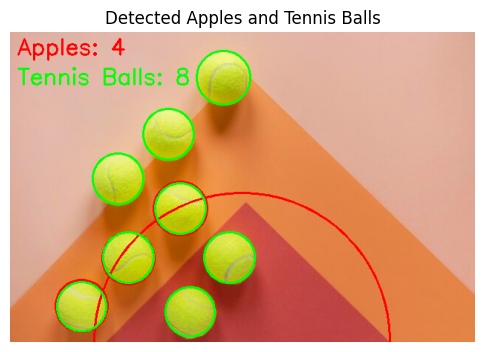

True

In [18]:
# ================================
# Функция: детекция объектов (яблок и теннисных мячей)
# ================================
def detect_apples_and_tennis_balls(image):
    original_height, original_width = image.shape[:2]
    scale_size = 800
    if original_width > scale_size or original_height > scale_size:
        scale_factor = min(scale_size / original_width, scale_size / original_height)
        image = cv2.resize(image, (int(original_width * scale_factor), int(original_height * scale_factor)), interpolation=cv2.INTER_AREA)

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Цветовые диапазоны для яблок
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 100, 100])
    upper_red2 = np.array([180, 255, 255])
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    lower_yellow = np.array([20, 100, 100])
    upper_yellow = np.array([30, 255, 255])
    mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask_red = cv2.bitwise_or(mask_red1, mask_red2)
    mask_green = cv2.inRange(hsv, lower_green, upper_green)
    mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)
    mask_apples = cv2.bitwise_or(mask_red, mask_green)
    mask_apples = cv2.bitwise_or(mask_apples, mask_yellow)
    # Цветовой диапазон для теннисных мячей
    lower_tennis = np.array([25, 70, 70])
    upper_tennis = np.array([35, 255, 255])
    mask_tennis = cv2.inRange(hsv, lower_tennis, upper_tennis)

    # Поиск контуров для яблок
    contours_apples, _ = cv2.findContours(mask_apples, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    apples_count = 0
    for cnt in contours_apples:
        area = cv2.contourArea(cnt)
        if area > 3500:
            apples_count += 1
            (x, y), radius = cv2.minEnclosingCircle(cnt)
            center = (int(x), int(y))
            radius = int(radius)
            cv2.circle(image, center, radius, (0, 0, 255), 2)  # Красная обводка
    # Поиск контуров для теннисных мячей
    contours_tennis, _ = cv2.findContours(mask_tennis, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    tennis_count = 0
    for cnt in contours_tennis:
        area = cv2.contourArea(cnt)
        if area > 1000:
            tennis_count += 1
            (x, y), radius = cv2.minEnclosingCircle(cnt)
            center = (int(x), int(y))
            radius = int(radius)
            cv2.circle(image, center, radius, (0, 255, 0), 2)  # Зелёная обводка
    cv2.putText(image, f"Apples: {apples_count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.putText(image, f"Tennis Balls: {tennis_count}", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    return image

detected_image = detect_apples_and_tennis_balls(image.copy())
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(detected_image, cv2.COLOR_BGR2RGB))
plt.title("Detected Apples and Tennis Balls")
plt.axis('off')
plt.show()
cv2.imwrite('results/objects_detected.jpg', detected_image)